# comprension_eda.ipynb

## Propósito

Análisis Exploratorio de Datos (EDA) profundo del dataset histórico de créditos `Base_de_datos.xlsx`. Este notebook desarrolla los tres niveles de análisis previstos en el Proyecto Integrador:

- **Análisis univariable:** distribución y características de cada variable individualmente.
- **Análisis bivariable:** relación de cada variable predictora con la variable objetivo `Pago_atiempo`.
- **Análisis multivariable:** correlaciones, multicolinealidad y relaciones entre múltiples variables simultáneamente.

El notebook trabaja sobre el dataset **crudo**: las decisiones de imputación, encoding, transformación y eliminación de outliers se postergan al script `ft_engineering.py` (versión V1.1.0).

## Versión

**V1.0.1** - EDA completo.

## 0. Setup

Importaciones, configuración global y carga del dataset.

### 0.1 Importaciones

In [2]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Estadística: tests inferenciales y análisis de multicolinealidad
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Utilitarios
import warnings
warnings.filterwarnings('ignore')  # Suprime warnings menores para limpieza de output

# Confirmación de versiones
print(f'pandas:      {pd.__version__}')
print(f'numpy:       {np.__version__}')
print(f'seaborn:     {sns.__version__}')

pandas:      2.3.3
numpy:       2.4.6
seaborn:     0.13.2


### 0.2 Configuración global

Se establecen opciones de visualización para que las salidas sean consistentes y legibles a lo largo del notebook.

In [3]:
# Pandas: que no recorte columnas al mostrar DataFrames anchos
pd.set_option('display.max_columns', None)

# Pandas: mostrar números flotantes con 2 decimales, sin notación científica
pd.set_option('display.float_format', '{:.2f}'.format)

# Pandas: ancho máximo de columna (para que el texto largo no se corte)
pd.set_option('display.max_colwidth', 80)

# Seaborn: tema visual consistente para todos los gráficos
sns.set_theme(style='whitegrid', palette='deep', context='notebook')

# Matplotlib: resolución de figuras (más alto = más nítido)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

# Semilla para reproducibilidad (cualquier muestreo aleatorio será reproducible)
SEMILLA = 42
np.random.seed(SEMILLA)

# Paleta de colores estable para los dos valores del target
# Convención: rojo para riesgo (no paga), verde-azul para cumplimiento (paga)
COLORES_TARGET = {0: '#D9534F', 1: '#5BC0DE'}

print('Configuración global aplicada.')

Configuración global aplicada.


### 0.3 Carga del dataset

Este notebook carga el dataset de forma **independiente** de `Cargar_datos.ipynb`, conforme a la decisión metodológica de mantener cada notebook autocontenido.

In [4]:
# Ruta relativa desde mlops_pipeline/src/ hacia la raíz del repositorio
RUTA_DATASET = '../../Base_de_datos.xlsx'

df = pd.read_excel(RUTA_DATASET)

print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Dataset cargado: 10,763 filas x 23 columnas


## 1. Exploración inicial

Primera mirada al dataset: estructura, tipos, integridad y composición.

### 1.1 Dimensiones, tipos de datos y vistazo a las filas

In [5]:
print(f'Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print(f'\nTipos de datos detectados por pandas:')
df.dtypes.value_counts().to_frame('cantidad_columnas')

Dimensiones: 10,763 filas x 23 columnas
Memoria utilizada: 2.85 MB

Tipos de datos detectados por pandas:


,cantidad_columnas
int64,12
float64,8
object,2
datetime64[ns],1


In [6]:
# Detalle por columna
tipos_detalle = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_unicos': df.nunique(dropna=True),
    'n_nulos': df.isnull().sum(),
    'pct_nulos': (df.isnull().sum() / len(df) * 100).round(2)
})
tipos_detalle

,dtype,n_unicos,n_nulos,pct_nulos
tipo_credito,int64,6,0,0.00
fecha_prestamo,datetime64[ns],10758,0,0.00
capital_prestado,float64,7306,0,0.00
plazo_meses,int64,18,0,0.00
edad_cliente,int64,54,0,0.00
tipo_laboral,object,2,0,0.00
salario_cliente,int64,1385,0,0.00
total_otros_prestamos,int64,1538,0,0.00
cuota_pactada,int64,9836,0,0.00
puntaje,float64,248,0,0.00


In [7]:
# Primeras 5 filas
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.00,10,42,Independiente,8000000,2500000,341296,88.77,695.00,10,5,0.00,51258.00,51258.00,0.00,5,0,0,908526.00,Estable,1
1,4,2025-04-22 09:47:35,840000.00,6,60,Empleado,3000000,2000000,124876,95.23,789.00,3,1,0.00,8673.00,8673.00,0.00,0,0,2,939017.00,Creciente,1
2,9,2026-01-08 12:22:40,5974028.40,10,36,Independiente,4036000,829000,529554,47.61,740.00,4,5,0.00,18702.00,18702.00,0.00,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.00,6,48,Empleado,1524547,498000,252420,95.23,837.00,4,4,0.00,15782.00,15782.00,0.00,3,0,0,1536193.00,Creciente,1
4,9,2025-04-26 11:24:26,2781636.00,11,44,Empleado,5000000,4000000,217037,95.23,771.00,4,6,0.00,204804.00,204804.00,0.00,3,0,1,933473.00,Creciente,1


In [8]:
# Últimas 5 filas (útil para verificar consistencia al final del dataset)
df.tail()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
10758,9,2025-01-19 16:18:28,2414886.00,10,29,Independiente,3000000,300000,204819,13.13,747.00,2,2,172.00,1112.00,1112.00,NaN,0,0,1,NaN,NaN,0
10759,4,2025-01-10 16:40:21,2916000.00,24,27,Empleado,2500000,400000,127460,55.97,714.00,5,4,0.00,9771.00,9771.00,0.00,1,0,4,1958333.00,Creciente,0
10760,4,2025-06-19 14:28:47,4249200.00,36,24,Empleado,2000000,500000,140042,47.61,807.00,2,2,0.00,1603.00,1603.00,0.00,1,0,0,998859.00,Creciente,0
10761,9,2025-03-02 11:53:41,1283307.60,10,26,Empleado,1500000,600000,108958,42.89,755.00,5,3,0.00,8488.00,8488.00,0.00,2,0,3,NaN,NaN,0
10762,4,2024-12-08 12:46:03,3915000.00,12,24,Independiente,4000000,2000000,306174,59.32,716.00,9,7,0.00,5046.00,5046.00,0.00,2,1,1,NaN,NaN,0


### 1.2 Valores nulos y duplicados

Identificación de columnas con valores faltantes y evaluación de filas duplicadas.

In [9]:
# Resumen de nulos por columna, ordenado descendentemente
nulos_resumen = pd.DataFrame({
    'n_nulos': df.isnull().sum(),
    'pct_nulos': (df.isnull().sum() / len(df) * 100).round(2)
})
nulos_resumen = nulos_resumen[nulos_resumen['n_nulos'] > 0].sort_values(
    'n_nulos', ascending=False
)
print(f'Columnas con valores nulos: {len(nulos_resumen)} de {len(df.columns)}')
nulos_resumen

Columnas con valores nulos: 7 de 23


,n_nulos,pct_nulos
tendencia_ingresos,2932,27.24
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_mora,156,1.45
saldo_total,156,1.45
puntaje_datacredito,6,0.06


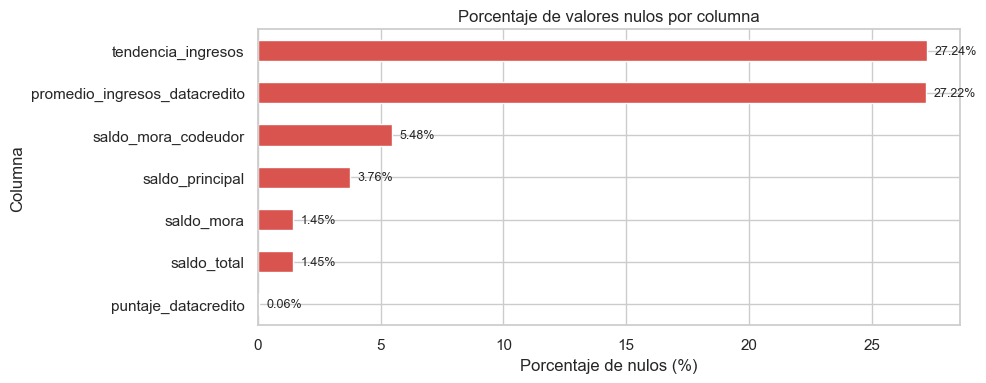

In [10]:
# Visualización: porcentaje de nulos por columna (solo las que tienen)
fig, ax = plt.subplots(figsize=(10, 4))
nulos_resumen['pct_nulos'].plot(kind='barh', ax=ax, color='#D9534F')
ax.set_xlabel('Porcentaje de nulos (%)')
ax.set_ylabel('Columna')
ax.set_title('Porcentaje de valores nulos por columna')
ax.invert_yaxis()  # La columna con más nulos arriba
for i, v in enumerate(nulos_resumen['pct_nulos']):
    ax.text(v + 0.3, i, f'{v:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [11]:
# Duplicados (filas completamente idénticas)
n_duplicados = df.duplicated().sum()
print(f'Filas duplicadas: {n_duplicados}')
if n_duplicados > 0:
    print('\nMuestra de duplicados:')
    print(df[df.duplicated(keep=False)].head())

Filas duplicadas: 0


### 1.3 Estadísticas descriptivas

Resumen estadístico de variables numéricas y conteos para variables categóricas.

In [12]:
# Estadísticas para variables numéricas
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
tipo_credito,10763.00,5.41,2.34,4.00,4.00,4.00,9.00,68.00
capital_prestado,10763.00,2434315.00,1909642.76,360000.00,1224831.00,1921920.00,3084840.00,41444152.80
plazo_meses,10763.00,10.58,6.63,2.00,6.00,10.00,12.00,90.00
edad_cliente,10763.00,43.95,15.06,19.00,33.00,42.00,53.00,123.00
salario_cliente,10763.00,17216431.46,355476717.60,0.00,2000000.00,3000000.00,4875808.00,22000000000.00
total_otros_prestamos,10763.00,6238869.65,118418316.94,0.00,500000.00,1000000.00,2000000.00,6787675263.00
cuota_pactada,10763.00,243617.41,210493.69,23944.00,121041.50,182863.00,287833.50,3816752.00
puntaje,10763.00,91.17,16.47,-38.01,95.23,95.23,95.23,95.23
puntaje_datacredito,10757.00,780.79,104.88,-7.00,757.00,791.00,825.00,999.00
cant_creditosvigentes,10763.00,5.73,3.98,0.00,3.00,5.00,8.00,62.00


In [13]:
# Estadísticas para variables NO numéricas (object/string + datetime)
df.describe(include=['object', 'datetime']).T

,count,unique,top,freq,mean,min,25%,50%,75%,max
fecha_prestamo,10763,NaN,NaN,NaN,2025-04-16 23:06:02.111121664,2024-11-26 09:17:04,2025-01-20 17:33:07.500000,2025-03-27 16:23:12,2025-06-16 13:27:58,2026-04-26 18:43:52
tipo_laboral,10763,2,Empleado,6754,NaN,NaN,NaN,NaN,NaN,NaN
tendencia_ingresos,7831,46,Creciente,5294,NaN,NaN,NaN,NaN,NaN,NaN


### 1.4 Clasificación de variables

Para tratar cada variable según su naturaleza, se construye una función helper que las clasifica en categorías. La heurística pura no es suficiente: hay variables enteras con pocos valores únicos que son **cantidades** (plazo_meses, cant_creditosvigentes) y otras que son **códigos categóricos** (tipo_credito). Por ello, el helper combina heurística automática con una **lista explícita** de variables que son categóricas codificadas.

In [14]:
# Lista explícita de variables que son categóricas codificadas en formato numérico.
# Estas variables tienen pocos valores únicos pero esos valores son códigos, no cantidades.
CATEGORICAS_CODIFICADAS = [
    'tipo_credito',         # Códigos discretos [4, 6, 7, 9, 10, 68] - claramente IDs
    'saldo_mora_codeudor',  # Solo 4 valores únicos [0, 30, 470, 2145], parece categorizado
]

# Lista explícita de columnas especiales
COL_TARGET = 'Pago_atiempo'
COL_FECHA = 'fecha_prestamo'

def clasificar_variables(df, umbral_discreta=20):
    """
    Clasifica las columnas del DataFrame en categorías para guiar el análisis.
    
    Categorías:
    - target: la variable objetivo del modelo.
    - fecha: la columna temporal.
    - categorica_texto: dtype 'object'/'string'.
    - categorica_codificada: numéricas que son códigos (definidas explícitamente).
    - numerica_discreta: numéricas con <= umbral valores únicos (cantidades enteras).
    - numerica_continua: numéricas con > umbral valores únicos.
    
    Returns
    -------
    dict
        Diccionario con las listas de columnas por cada categoría.
    """
    clasif = {
        'target': [],
        'fecha': [],
        'categorica_texto': [],
        'categorica_codificada': [],
        'numerica_discreta': [],
        'numerica_continua': []
    }
    
    for col in df.columns:
        if col == COL_TARGET:
            clasif['target'].append(col)
        elif col == COL_FECHA:
            clasif['fecha'].append(col)
        elif col in CATEGORICAS_CODIFICADAS:
            clasif['categorica_codificada'].append(col)
        elif df[col].dtype == 'object' or pd.api.types.is_string_dtype(df[col]):
            clasif['categorica_texto'].append(col)
        elif df[col].nunique(dropna=True) <= umbral_discreta:
            clasif['numerica_discreta'].append(col)
        else:
            clasif['numerica_continua'].append(col)
    
    return clasif

# Aplicar la clasificación
clasificacion = clasificar_variables(df)

# Mostrar la clasificación de forma legible
for tipo, columnas in clasificacion.items():
    print(f'{tipo} ({len(columnas)}):')
    for c in columnas:
        print(f'  - {c}')
    print()

target (1):
  - Pago_atiempo

fecha (1):
  - fecha_prestamo

categorica_texto (2):
  - tipo_laboral
  - tendencia_ingresos

categorica_codificada (2):
  - tipo_credito
  - saldo_mora_codeudor

numerica_discreta (2):
  - plazo_meses
  - creditos_sectorCooperativo

numerica_continua (15):
  - capital_prestado
  - edad_cliente
  - salario_cliente
  - total_otros_prestamos
  - cuota_pactada
  - puntaje
  - puntaje_datacredito
  - cant_creditosvigentes
  - huella_consulta
  - saldo_mora
  - saldo_total
  - saldo_principal
  - creditos_sectorFinanciero
  - creditos_sectorReal
  - promedio_ingresos_datacredito



### 1.5 Análisis del target: `Pago_atiempo`

La variable objetivo es binaria: 1 si el cliente paga a tiempo, 0 si no.

Su distribución es crítica para el modelado, ya que define la dificultad del problema.

In [15]:
# Distribución del target en frecuencias absolutas y relativas
target_abs = df[COL_TARGET].value_counts(dropna=False)
target_rel = df[COL_TARGET].value_counts(normalize=True, dropna=False) * 100

resumen_target = pd.DataFrame({
    'frecuencia': target_abs,
    'porcentaje': target_rel.round(2)
})
print('Distribución de la variable objetivo:')
print(resumen_target)

# Cálculo del ratio de desbalance
if 0 in target_abs.index and 1 in target_abs.index:
    ratio_desbalance = target_abs[1] / target_abs[0]
    print(f'\nRatio clase 1 / clase 0: {ratio_desbalance:.2f}')
    print(f'Por cada cliente que NO paga a tiempo, hay {ratio_desbalance:.1f} que SÍ pagan.')

Distribución de la variable objetivo:
              frecuencia  porcentaje
Pago_atiempo                        
1                  10252       95.25
0                    511        4.75

Ratio clase 1 / clase 0: 20.06
Por cada cliente que NO paga a tiempo, hay 20.1 que SÍ pagan.


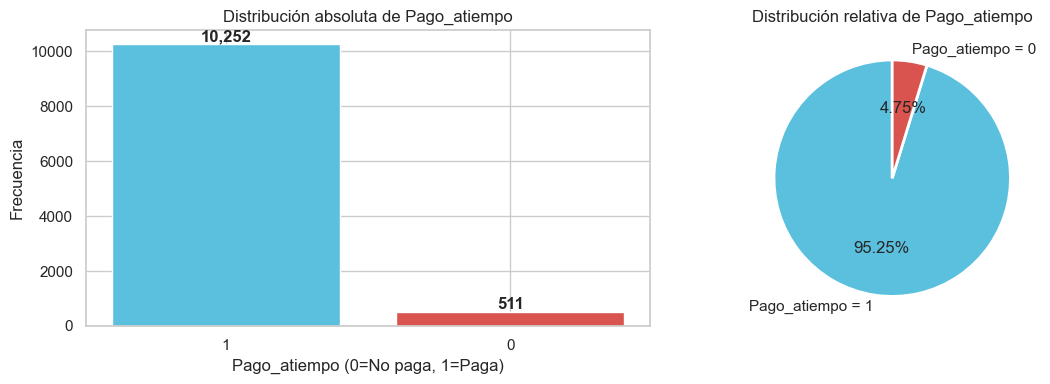

In [16]:
# Visualización del balance del target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Subplot 1: barras de frecuencia absoluta
colores = [COLORES_TARGET[v] for v in target_abs.index]
axes[0].bar(target_abs.index.astype(str), target_abs.values, color=colores)
axes[0].set_title('Distribución absoluta de Pago_atiempo')
axes[0].set_xlabel('Pago_atiempo (0=No paga, 1=Paga)')
axes[0].set_ylabel('Frecuencia')
for i, v in enumerate(target_abs.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Subplot 2: pastel con porcentajes
axes[1].pie(
    target_abs.values,
    labels=[f'Pago_atiempo = {v}' for v in target_abs.index],
    autopct='%1.2f%%',
    colors=colores,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Distribución relativa de Pago_atiempo')

plt.tight_layout()
plt.show()

### 1.6 Observaciones del dataset crudo

Tras la exploración inicial, se identifican los siguientes puntos de atención que orientarán el resto del análisis y la futura ingeniería de características:

**Sobre los nulos:**

- `tendencia_ingresos` y `promedio_ingresos_datacredito` presentan ~27% de nulos cada una. Su conteo casi idéntico sugiere que ambos campos provienen de la misma fuente externa (probablemente DataCrédito) y faltan conjuntamente cuando esa fuente no devolvió información para el cliente.
- `saldo_mora_codeudor` tiene 5.48% de nulos, posiblemente vinculados a créditos sin codeudor.
- `saldo_principal`, `saldo_mora` y `saldo_total` presentan nulos menores (<4%) que requerirán imputación.

**Sobre las variables categóricas codificadas:**

- `tipo_credito` tiene 6 valores únicos `[4, 6, 7, 9, 10, 68]` que claramente son códigos identificadores, no cantidades. Se trata como variable categórica.
- `saldo_mora_codeudor` tiene únicamente 4 valores únicos `[0.0, 30.0, 470.0, 2145.0]`. Aunque su nombre sugiere un monto continuo, su distribución tan discreta sugiere que viene pre-categorizada. Se trata como categórica codificada.

**Sobre la calidad de `tendencia_ingresos`:**

- Esta variable mezcla categorías de texto ('Creciente', 'Decreciente', 'Estable') con valores numéricos en formato texto ('0', '8315', '1000000', etc.). Las tres categorías de texto suman ~99% de los valores no nulos; el resto son anomalías que deberán limpiarse en la fase de feature engineering.

**Sobre `tipo_laboral`:**

- Variable categórica de texto binaria con valores `'Empleado'` y `'Independiente'`. No presenta nulos.

**Sobre el desbalance del target:**

- `Pago_atiempo` está severamente desbalanceado (~95% pagan, ~5% no pagan). Esto tiene implicaciones críticas para el modelado:
    - La métrica `accuracy` será engañosa (un modelo que prediga siempre 'paga' tendrá ~95% de acierto sin aprender nada útil).
    - Se deberán usar métricas más informativas como ROC-AUC, F1-score y Precision-Recall, tal como exige el Proyecto Integrador.
    - El desbalance se manejará en el entrenamiento mediante `class_weight='balanced'`, `scale_pos_weight` (XGBoost) o técnicas de resampling.
    - La **clase de interés desde el negocio** es la minoritaria (clase 0, los que NO pagan a tiempo), ya que representan el riesgo crediticio que se busca anticipar.


## 2. Análisis univariable

Estudio individual de cada variable: su distribución, valores extremos y forma. El análisis se segmenta según el tipo de variable identificado en la sección anterior.

### 2.1 Variables numéricas continuas

Se generan histogramas y boxplots para cada variable continua. Dado que varias presentan asimetría extrema (skewness > 5), se aplica escala logarítmica en el eje X para que las distribuciones sean legibles. El boxplot complementa el histograma resaltando la mediana, los cuartiles y los puntos atípicos.

In [17]:
# Función auxiliar: decide si una variable requiere escala log
# basándose en su asimetría (skewness) y rango.
def requiere_escala_log(serie, umbral_skew=2.0):
    """
    Devuelve True si la variable es muy asimétrica positivamente y
    todos sus valores son no negativos (precondición de log10).
    """
    serie_clean = serie.dropna()
    if serie_clean.min() < 0:
        return False  # log no aplicable a negativos
    return abs(serie_clean.skew()) > umbral_skew

# Función auxiliar: dibuja histograma + boxplot para una variable continua
def plot_continua_univariable(serie, nombre_var, ax_hist, ax_box):
    """
    Grafica un histograma (con KDE) y un boxplot horizontal en los ejes dados.
    Aplica escala log al eje X si la variable es muy asimétrica.
    """
    datos = serie.dropna()
    usar_log = requiere_escala_log(serie) and datos.min() >= 0
    
    # Si hay ceros y queremos log, se suma 1 (transformación log1p)
    if usar_log:
        datos_plot = np.log1p(datos)
        sufijo = ' (escala log1p)'
    else:
        datos_plot = datos
        sufijo = ''
    
    # Histograma con curva de densidad
    sns.histplot(datos_plot, kde=True, ax=ax_hist, color='steelblue', edgecolor='white')
    ax_hist.set_title(f'{nombre_var}{sufijo}', fontsize=10)
    ax_hist.set_xlabel('')
    ax_hist.set_ylabel('Frecuencia')
    
    # Boxplot horizontal
    sns.boxplot(x=datos_plot, ax=ax_box, color='lightblue')
    ax_box.set_xlabel(f'Valor{sufijo}')

print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


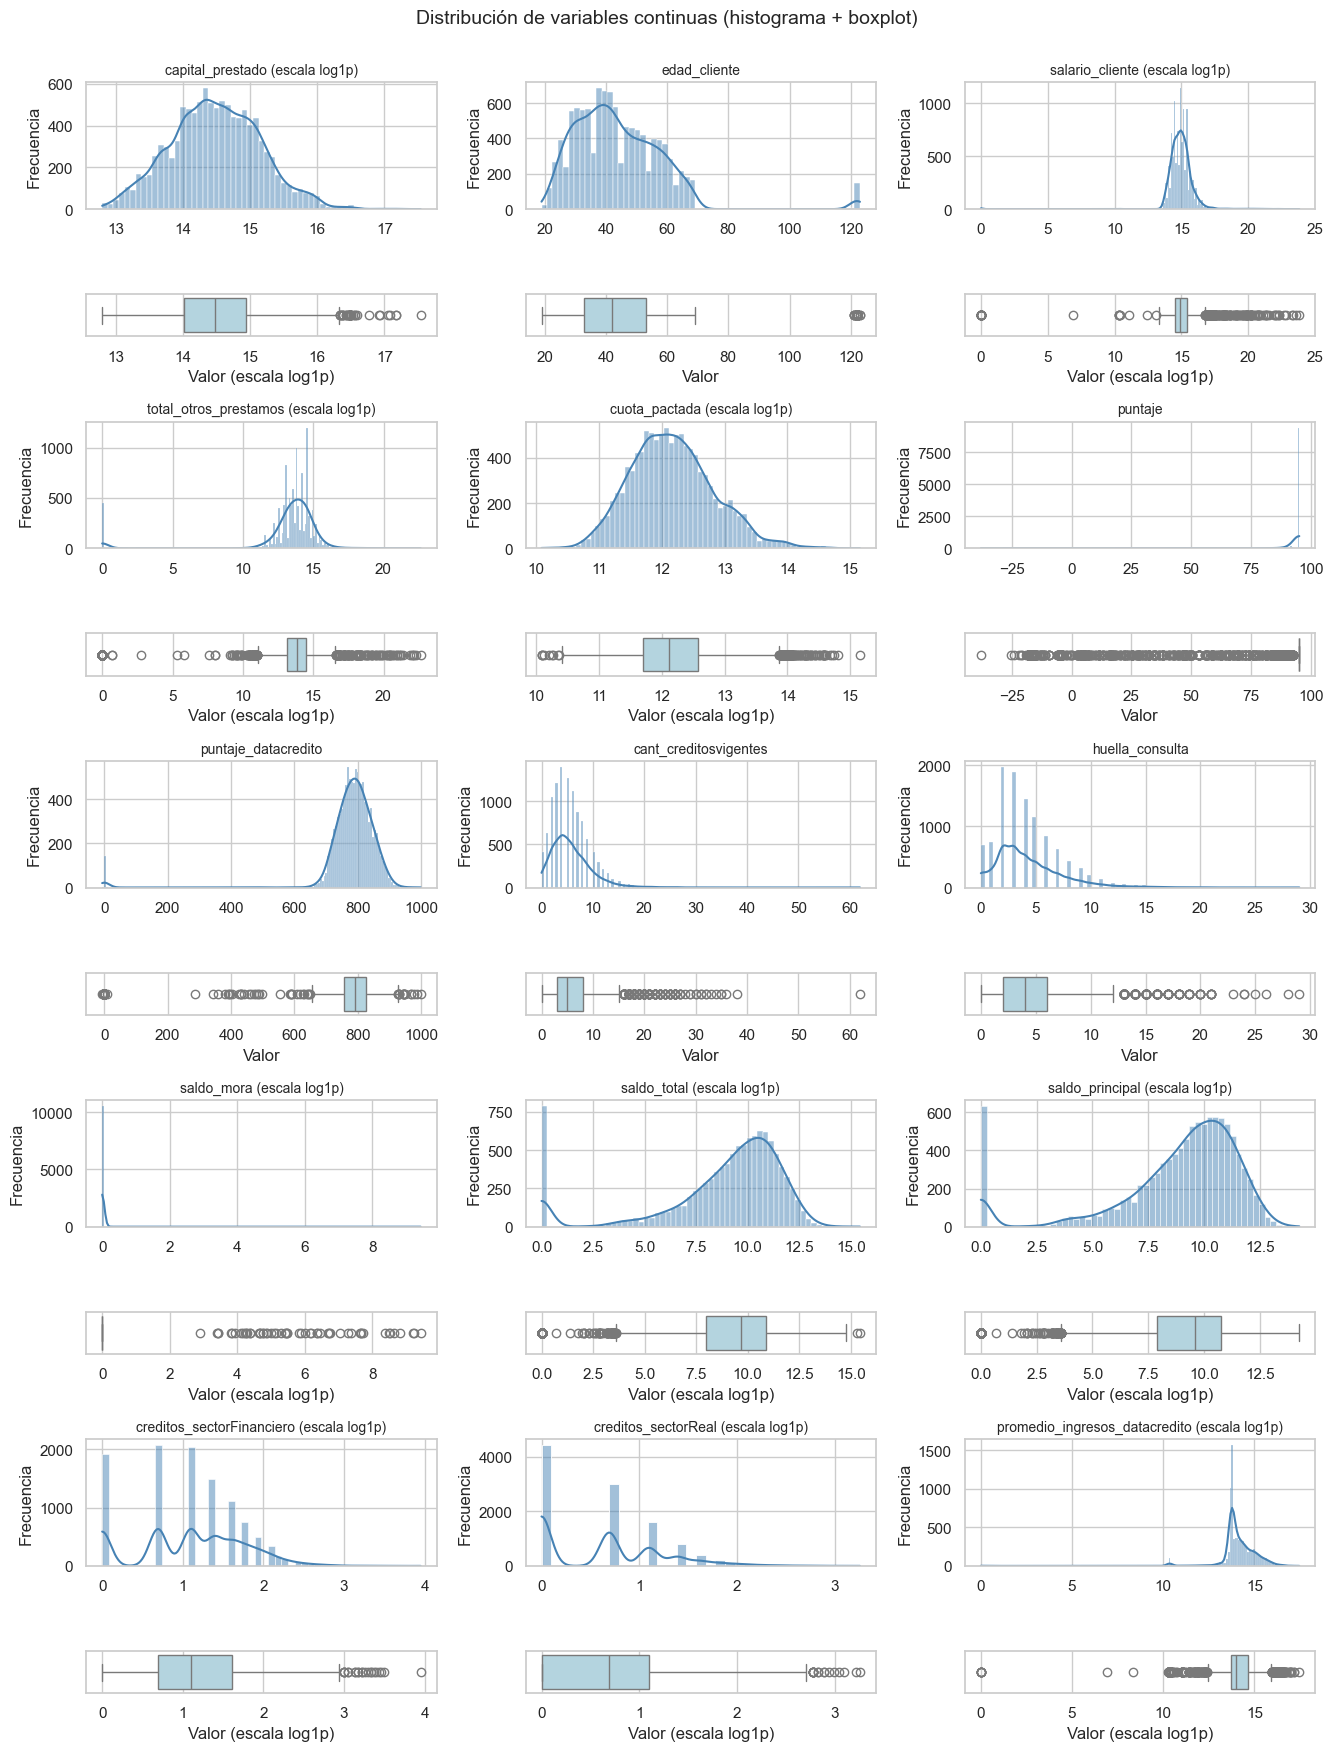

In [18]:
# Generar la grilla de histogramas + boxplots para todas las continuas
variables_continuas = clasificacion['numerica_continua']
n_vars = len(variables_continuas)

# Grilla: cada variable ocupa 2 filas (histograma arriba, boxplot abajo) y 1 columna.
# Distribuimos 4 variables por fila lógica → 8 sub-filas de altura, n_vars/4 columnas.
n_cols = 3
n_filas_logicas = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(
    n_filas_logicas * 2,  # 2 ejes por variable (hist + box)
    n_cols,
    figsize=(n_cols * 4.5, n_filas_logicas * 3.5),
    gridspec_kw={'height_ratios': [3, 1] * n_filas_logicas}
)

for i, var in enumerate(variables_continuas):
    fila_logica = i // n_cols
    col = i % n_cols
    ax_hist = axes[fila_logica * 2, col]
    ax_box = axes[fila_logica * 2 + 1, col]
    plot_continua_univariable(df[var], var, ax_hist, ax_box)

# Limpiar los ejes sobrantes (si n_vars no es múltiplo de n_cols)
total_ejes = n_filas_logicas * n_cols
for i in range(n_vars, total_ejes):
    fila_logica = i // n_cols
    col = i % n_cols
    axes[fila_logica * 2, col].axis('off')
    axes[fila_logica * 2 + 1, col].axis('off')

plt.suptitle('Distribución de variables continuas (histograma + boxplot)', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

### 2.2 Variables numéricas discretas

Variables con pocos valores enteros distintos que representan cantidades (no códigos). Se grafican como barras de frecuencia.

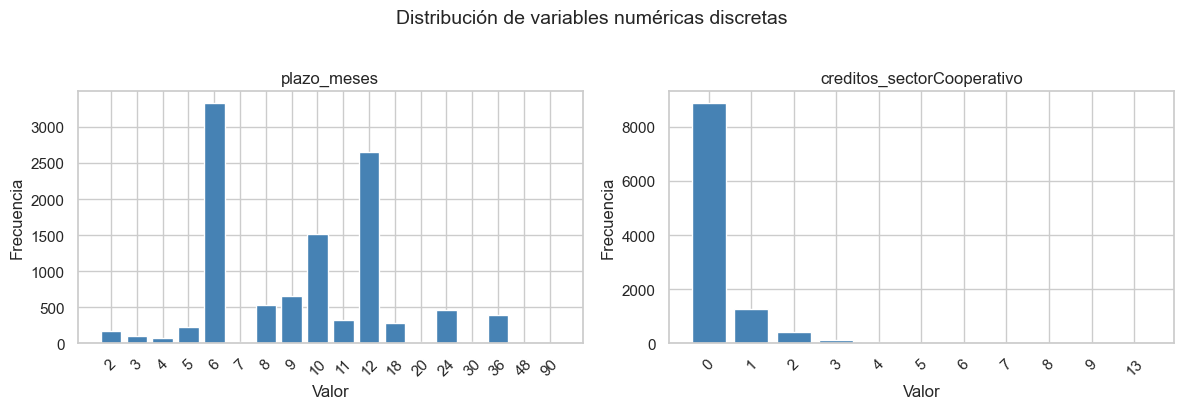

In [19]:
variables_discretas = clasificacion['numerica_discreta']

if variables_discretas:
    n_vars = len(variables_discretas)
    n_cols = min(n_vars, 2)
    n_filas = int(np.ceil(n_vars / n_cols))
    
    fig, axes = plt.subplots(n_filas, n_cols, figsize=(n_cols * 6, n_filas * 4))
    if n_vars == 1:
        axes = np.array([axes])
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    
    for i, var in enumerate(variables_discretas):
        conteos = df[var].value_counts().sort_index()
        axes[i].bar(conteos.index.astype(str), conteos.values, color='steelblue', edgecolor='white')
        axes[i].set_title(f'{var}')
        axes[i].set_xlabel('Valor')
        axes[i].set_ylabel('Frecuencia')
        # Rotar etiquetas si hay muchas
        if len(conteos) > 10:
            axes[i].tick_params(axis='x', rotation=45)
    
    # Limpiar ejes sobrantes
    for i in range(n_vars, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('Distribución de variables numéricas discretas', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No hay variables numéricas discretas en esta clasificación.')

### 2.3 Variables categóricas (texto y codificadas)

Se grafican como barras de frecuencia. Las codificadas (`tipo_credito`, `saldo_mora_codeudor`) se tratan igual que las de texto: importa la distribución de categorías, no su valor numérico. Para `tendencia_ingresos`, dada su alta cardinalidad, se muestran solo las categorías Top-N más frecuentes.

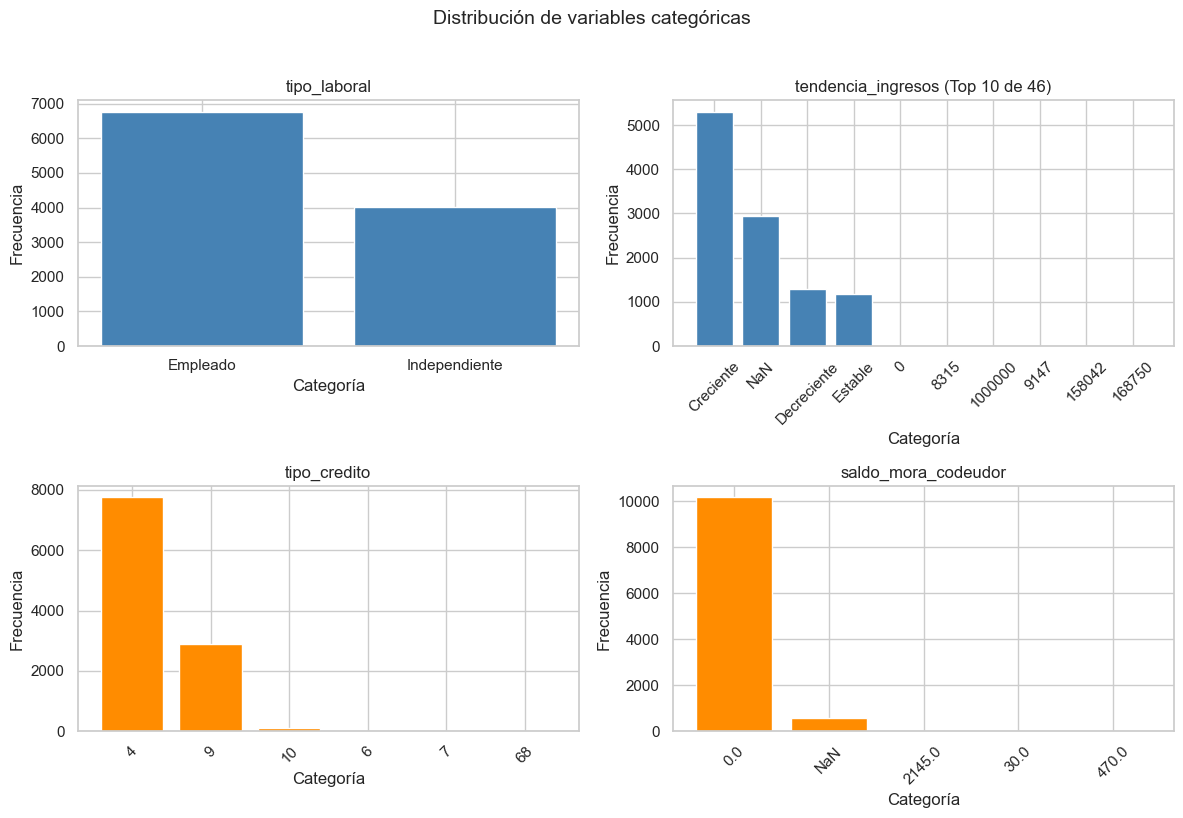

In [20]:
variables_categoricas = (
    clasificacion['categorica_texto'] +
    clasificacion['categorica_codificada']
)
n_vars = len(variables_categoricas)
n_cols = 2
n_filas = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_filas, n_cols, figsize=(n_cols * 6, n_filas * 4))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

TOP_N = 10  # Para variables de alta cardinalidad

for i, var in enumerate(variables_categoricas):
    conteos = df[var].value_counts(dropna=False)
    es_truncado = False
    if len(conteos) > TOP_N:
        conteos = conteos.head(TOP_N)
        es_truncado = True
    
    # Convertir índice (puede tener NaN) a string para graficar
    etiquetas = [str(x) if pd.notna(x) else 'NaN' for x in conteos.index]
    
    color = 'darkorange' if var in clasificacion['categorica_codificada'] else 'steelblue'
    axes[i].bar(etiquetas, conteos.values, color=color, edgecolor='white')
    titulo = f'{var}'
    if es_truncado:
        titulo += f' (Top {TOP_N} de {df[var].nunique()})'
    axes[i].set_title(titulo)
    axes[i].set_xlabel('Categoría')
    axes[i].set_ylabel('Frecuencia')
    if len(etiquetas) > 4:
        axes[i].tick_params(axis='x', rotation=45)

# Limpiar ejes sobrantes
for i in range(n_vars, len(axes)):
    axes[i].axis('off')

plt.suptitle('Distribución de variables categóricas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.4 Variable temporal: `fecha_prestamo`

Se analiza el rango temporal del dataset y la distribución de préstamos a lo largo del tiempo, agregando por mes para ver tendencias.

In [21]:
col_fecha = 'fecha_prestamo'
print(f'Rango temporal del dataset:')
print(f'  Fecha mínima: {df[col_fecha].min()}')
print(f'  Fecha máxima: {df[col_fecha].max()}')
print(f'  Span:         {(df[col_fecha].max() - df[col_fecha].min()).days} días')

Rango temporal del dataset:
  Fecha mínima: 2024-11-26 09:17:04
  Fecha máxima: 2026-04-26 18:43:52
  Span:         516 días


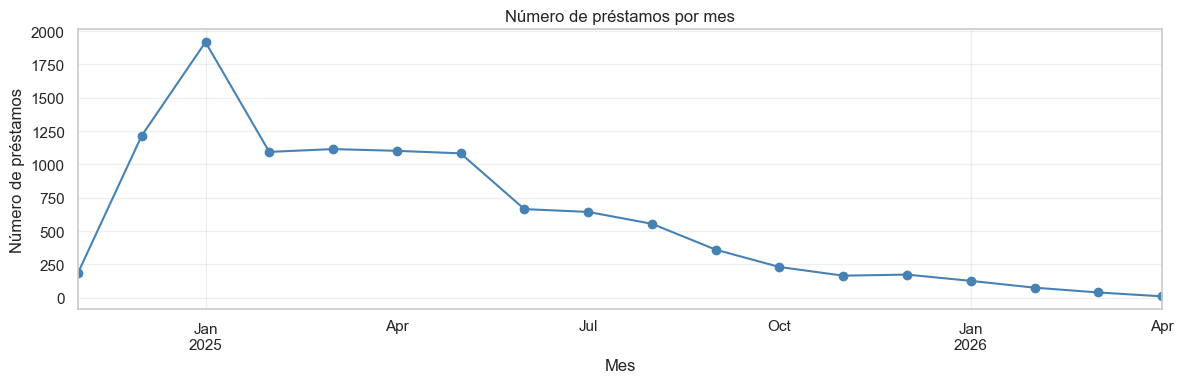

In [22]:
# Agregación por mes
prestamos_por_mes = df.set_index(col_fecha).resample('ME').size()

fig, ax = plt.subplots(figsize=(12, 4))
prestamos_por_mes.plot(kind='line', ax=ax, marker='o', color='steelblue')
ax.set_title('Número de préstamos por mes')
ax.set_xlabel('Mes')
ax.set_ylabel('Número de préstamos')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.5 Detección de outliers

Para cada variable numérica continua se calculan los outliers según la **regla del IQR** (Tukey): valores fuera del rango `[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]` se consideran atípicos.

Esta detección es **diagnóstica**, no transformadora: ningún valor es eliminado aquí. La decisión sobre tratamiento de outliers se posterga a la fase de feature engineering.

In [23]:
def detectar_outliers_iqr(serie):
    """
    Aplica la regla IQR para detectar outliers en una variable numérica.
    
    Returns
    -------
    dict con métricas:
        q1, q3, iqr, limite_inferior, limite_superior,
        n_outliers_bajos, n_outliers_altos, pct_outliers, valor_min, valor_max.
    """
    s = serie.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_low = (s < li).sum()
    n_high = (s > ls).sum()
    n_total = n_low + n_high
    return {
        'q1': q1, 'q3': q3, 'iqr': iqr,
        'limite_inferior': li, 'limite_superior': ls,
        'n_outliers_bajos': n_low, 'n_outliers_altos': n_high,
        'n_outliers_total': n_total,
        'pct_outliers': round(n_total / len(s) * 100, 2),
        'valor_min': s.min(), 'valor_max': s.max()
    }

# Tabla resumen de outliers para variables continuas
resumen_outliers = pd.DataFrame({
    var: detectar_outliers_iqr(df[var])
    for var in clasificacion['numerica_continua']
}).T

# Ordenar por porcentaje de outliers descendente
resumen_outliers = resumen_outliers.sort_values('pct_outliers', ascending=False)
resumen_outliers

,q1,q3,iqr,limite_inferior,limite_superior,n_outliers_bajos,n_outliers_altos,n_outliers_total,pct_outliers,valor_min,valor_max
puntaje,95.23,95.23,0.00,95.23,95.23,1356.00,0.00,1356.00,12.60,-38.01,95.23
promedio_ingresos_datacredito,925157.00,2231859.00,1306702.00,-1034896.00,4191912.00,0.00,784.00,784.00,10.01,0.00,38106581.00
saldo_principal,2690.00,47632.25,44942.25,-64723.38,115045.62,0.00,951.00,951.00,9.18,0.00,1562285.00
saldo_total,2898.00,52982.00,50084.00,-72228.00,128108.00,0.00,970.00,970.00,9.14,0.00,5116066.00
cuota_pactada,121041.50,287833.50,166792.00,-129146.50,538021.50,0.00,765.00,765.00,7.11,23944.00,3816752.00
salario_cliente,2000000.00,4875808.00,2875808.00,-2313712.00,9189520.00,0.00,718.00,718.00,6.67,0.00,22000000000.00
total_otros_prestamos,500000.00,2000000.00,1500000.00,-1750000.00,4250000.00,0.00,589.00,589.00,5.47,0.00,6787675263.00
capital_prestado,1224831.00,3084840.00,1860009.00,-1565182.50,5874853.50,0.00,550.00,550.00,5.11,360000.00,41444152.80
creditos_sectorFinanciero,1.00,4.00,3.00,-3.50,8.50,0.00,364.00,364.00,3.38,0.00,51.00
creditos_sectorReal,0.00,2.00,2.00,-3.00,5.00,0.00,350.00,350.00,3.25,0.00,25.00


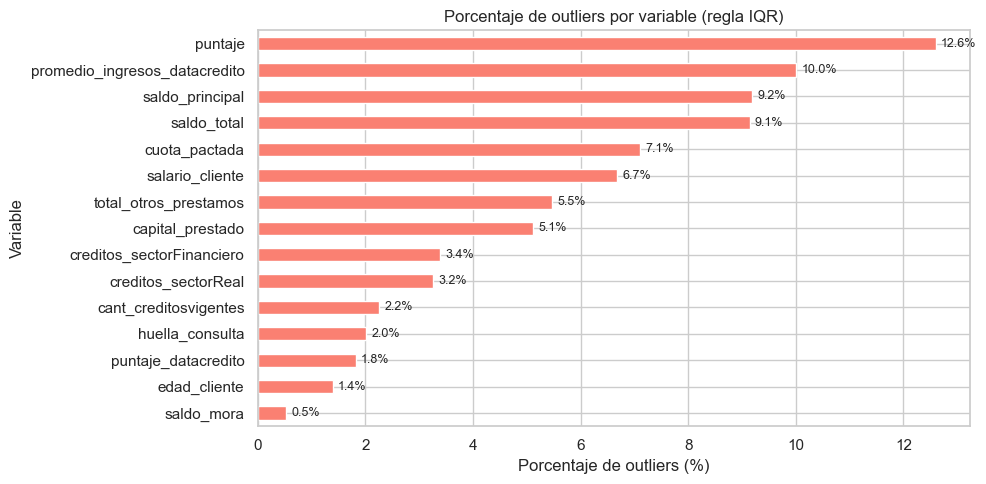

In [24]:
# Visualización: porcentaje de outliers por variable
fig, ax = plt.subplots(figsize=(10, 5))
resumen_outliers['pct_outliers'].plot(kind='barh', ax=ax, color='salmon')
ax.set_xlabel('Porcentaje de outliers (%)')
ax.set_ylabel('Variable')
ax.set_title('Porcentaje de outliers por variable (regla IQR)')
ax.invert_yaxis()
for i, v in enumerate(resumen_outliers['pct_outliers']):
    ax.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 2.6 Valores extremos sospechosos

Más allá de los outliers estadísticos por IQR, se documentan valores extremos cuya **semántica de negocio** los hace sospechosos. Estos no son necesariamente errores, pero merecen revisión en la fase de limpieza.

In [25]:
# Casos específicos a revisar
casos_sospechosos = pd.DataFrame({
    'variable': [
        'edad_cliente',
        'salario_cliente',
        'puntaje_datacredito',
        'puntaje',
        'total_otros_prestamos',
        'capital_prestado',
    ],
    'valor_min': [
        df['edad_cliente'].min(),
        df['salario_cliente'].min(),
        df['puntaje_datacredito'].min(),
        df['puntaje'].min(),
        df['total_otros_prestamos'].min(),
        df['capital_prestado'].min(),
    ],
    'valor_max': [
        df['edad_cliente'].max(),
        df['salario_cliente'].max(),
        df['puntaje_datacredito'].max(),
        df['puntaje'].max(),
        df['total_otros_prestamos'].max(),
        df['capital_prestado'].max(),
    ],
    'observacion': [
        'Edad max=123 anos es biologicamente improbable; revisar registros >100.',
        'Salario max=22 mil millones es imposible mensualmente; probable error de captura.',
        'DataCredito va de 150 a 950 nominalmente; valores negativos son anomalias.',
        'Valor maximo igual a la mediana sugiere posible truncamiento.',
        'Maximo de 6.7 mil millones revisar si es correcto.',
        'Maximo de 41 millones COP es alto pero plausible para credito grande.',
    ]
})
casos_sospechosos

,variable,valor_min,valor_max,observacion
0,edad_cliente,19.00,123.00,Edad max=123 anos es biologicamente improbable; revisar registros >100.
1,salario_cliente,0.00,22000000000.00,Salario max=22 mil millones es imposible mensualmente; probable error de cap...
2,puntaje_datacredito,-7.00,999.00,DataCredito va de 150 a 950 nominalmente; valores negativos son anomalias.
3,puntaje,-38.01,95.23,Valor maximo igual a la mediana sugiere posible truncamiento.
4,total_otros_prestamos,0.00,6787675263.00,Maximo de 6.7 mil millones revisar si es correcto.
5,capital_prestado,360000.00,41444152.80,Maximo de 41 millones COP es alto pero plausible para credito grande.


### 2.7 Hallazgos del análisis univariable

**Sobre asimetría y distribuciones:**

- La mayoría de variables monetarias (`salario_cliente`, `total_otros_prestamos`, `capital_prestado`, `saldo_total`, `saldo_principal`, `saldo_mora`) presentan asimetría positiva extrema (skewness > 3), con colas muy largas hacia la derecha.
- Esto se debe a la concentración de valores pequeños/medios con presencia ocasional de valores muy altos, comportamiento típico de variables financieras.
- En feature engineering será conveniente aplicar transformaciones logarítmicas o de raíz cuadrada para reducir la asimetría antes del modelado.

**Sobre valores con asimetría negativa:**

- `puntaje` (skew = -4.87) y `puntaje_datacredito` (skew = -5.64) presentan asimetría negativa porque sus valores se concentran en la zona alta del rango.

**Sobre outliers (regla IQR):**

- Variables con altísimo porcentaje de outliers tienden a ser las muy asimétricas. La regla IQR detecta tantos puntos atípicos porque la distribución no es simétrica.
- Para estas variables, eliminar todos los outliers por IQR sería un error: estaríamos perdiendo información legítima. Se evaluará un enfoque más sensato en feature engineering (winsorization, transformación log, o conservar y dejar que el modelo decida).

**Sobre valores anómalos por semántica de negocio:**

- `edad_cliente` con máximo de 123 años es biológicamente implausible.
- `salario_cliente` con máximo de 22 mil millones es un error claro (probablemente captura errónea de pesos vs centavos).
- `puntaje_datacredito` con valores negativos rompe la escala nominal de DataCrédito.
- Estos casos deberán tratarse explícitamente en la limpieza (cap, eliminación o imputación).

**Sobre la variable temporal:**

- Los préstamos cubren un rango temporal específico cuya distribución se observa en la gráfica mensual. Si la composición temporal es desigual, podría introducir sesgos al modelo si los patrones de pago cambian en el tiempo (concept drift).

**Sobre las categóricas:**

- `tipo_laboral` está balanceada entre Empleado e Independiente.
- `tendencia_ingresos` tiene tres categorías dominantes (Creciente, Decreciente, Estable) y un "ruido" minoritario de valores numéricos que deberá limpiarse.
- `tipo_credito` (códigos 4, 6, 7, 9, 10, 68) muestra distribución desigual entre tipos.
- `saldo_mora_codeudor` está concentrada en el valor 0 (o NaN), reflejando que la mayoría de créditos no tienen codeudor o no presentan mora del mismo.

## 3. Análisis bivariable

Estudio de la relación de cada variable predictora con la variable objetivo `Pago_atiempo`. El objetivo es identificar qué variables tienen poder discriminativo entre clientes que pagan a tiempo (clase 1) y los que no (clase 0).

### 3.1 Variables numéricas vs target

Se grafica la **distribución de cada variable numérica condicionada por la clase del target**. Si las dos curvas (clase 0 vs clase 1) se solapan, la variable tiene poco poder discriminativo. Si están separadas, es informativa para el modelo.

Para variables continuas se usa estimación de densidad por kernel (KDE). Para variables discretas se usan barras agrupadas.

In [26]:
# Función auxiliar: KDE condicionada para una variable continua
def plot_kde_condicionado(serie, target, nombre_var, ax, usar_log=False):
    """
    Grafica dos curvas KDE superpuestas, una por cada valor del target.
    Se filtran nulos antes de graficar.
    """
    df_temp = pd.DataFrame({'valor': serie, 'target': target}).dropna()
    
    if usar_log and df_temp['valor'].min() >= 0:
        df_temp['valor'] = np.log1p(df_temp['valor'])
        sufijo = ' (log1p)'
    else:
        sufijo = ''
    
    for clase in sorted(df_temp['target'].unique()):
        subset = df_temp[df_temp['target'] == clase]['valor']
        sns.kdeplot(
            subset, ax=ax,
            label=f'Pago_atiempo={clase}',
            color=COLORES_TARGET[clase],
            fill=True, alpha=0.3
        )
    ax.set_title(f'{nombre_var}{sufijo}', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

print('Función plot_kde_condicionado definida.')

Función plot_kde_condicionado definida.


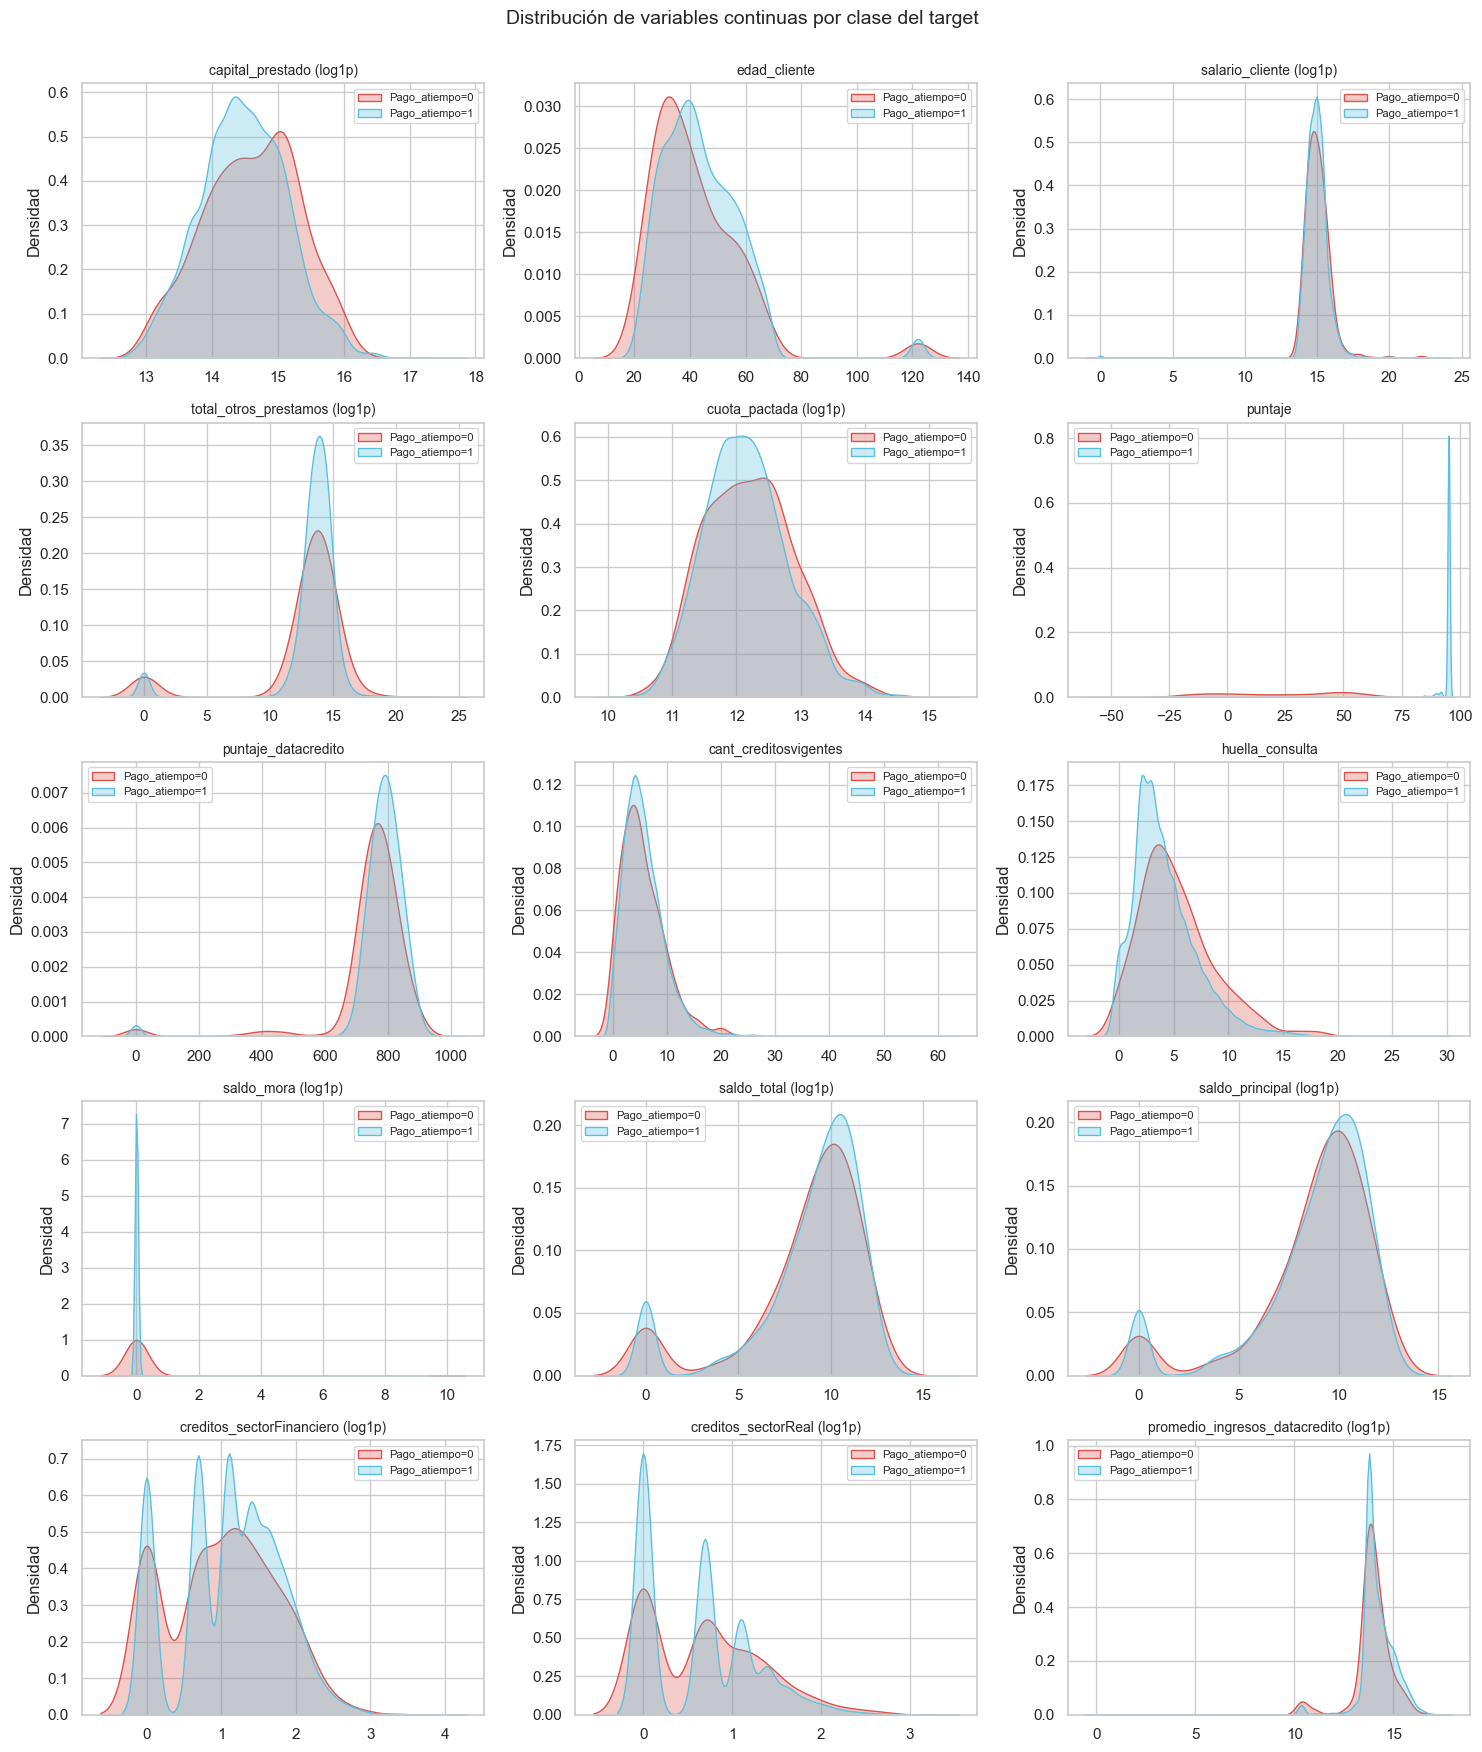

In [27]:
# Grilla de KDE condicionados para variables continuas
vars_continuas = clasificacion['numerica_continua']
n_vars = len(vars_continuas)
n_cols = 3
n_filas = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_filas, n_cols, figsize=(n_cols * 5, n_filas * 3.5))
axes = axes.flatten()

target_series = df[COL_TARGET]

for i, var in enumerate(vars_continuas):
    usar_log = requiere_escala_log(df[var])
    plot_kde_condicionado(df[var], target_series, var, axes[i], usar_log=usar_log)

# Limpiar ejes sobrantes
for i in range(n_vars, len(axes)):
    axes[i].axis('off')

plt.suptitle('Distribución de variables continuas por clase del target', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

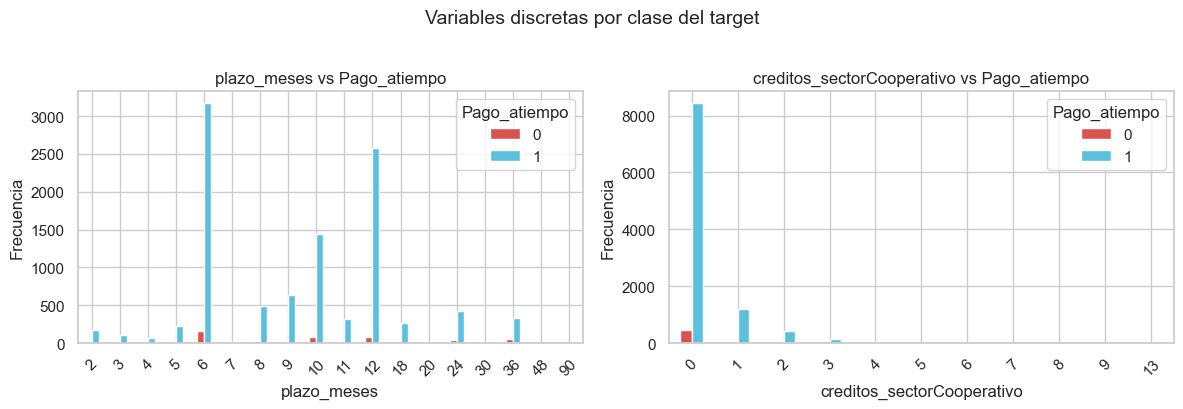

In [28]:
# Variables discretas: barras agrupadas por target
vars_discretas = clasificacion['numerica_discreta']
n_vars = len(vars_discretas)

if n_vars > 0:
    n_cols = min(n_vars, 2)
    n_filas = int(np.ceil(n_vars / n_cols))
    fig, axes = plt.subplots(n_filas, n_cols, figsize=(n_cols * 6, n_filas * 4))
    axes = np.array([axes]).flatten() if n_vars == 1 else axes.flatten()
    
    for i, var in enumerate(vars_discretas):
        # Crear tabla de contingencia variable x target
        ct = pd.crosstab(df[var], df[COL_TARGET])
        ct.plot(
            kind='bar', ax=axes[i],
            color=[COLORES_TARGET[c] for c in ct.columns],
            edgecolor='white'
        )
        axes[i].set_title(f'{var} vs Pago_atiempo')
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Frecuencia')
        axes[i].legend(title='Pago_atiempo')
        if len(ct) > 10:
            axes[i].tick_params(axis='x', rotation=45)
    
    for i in range(n_vars, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('Variables discretas por clase del target', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

### 3.2 Variables categóricas vs target

Para cada categoría se calcula la **tasa de Pago_atiempo** (proporción de clase 1). Si todas las categorías tienen la misma tasa (cercana a la tasa global ~95%), la variable no aporta. Si alguna categoría se desvía significativamente, es informativa.

In [29]:
# Función auxiliar: tasa de target=1 por categoría
def tasa_target_por_categoria(df, col_categorica, col_target):
    """
    Calcula la tasa de target=1 para cada nivel de la columna categórica.
    Incluye el conteo de muestras por categoría.
    """
    resumen = df.groupby(col_categorica, dropna=False)[col_target].agg(
        n_muestras='count',
        tasa_pago_atiempo='mean'
    )
    resumen['tasa_pago_atiempo'] = (resumen['tasa_pago_atiempo'] * 100).round(2)
    return resumen.sort_values('tasa_pago_atiempo', ascending=False)

# Tasa global como referencia
tasa_global = (df[COL_TARGET].mean() * 100)
print(f'Tasa global de Pago_atiempo = 1: {tasa_global:.2f}%')

Tasa global de Pago_atiempo = 1: 95.25%


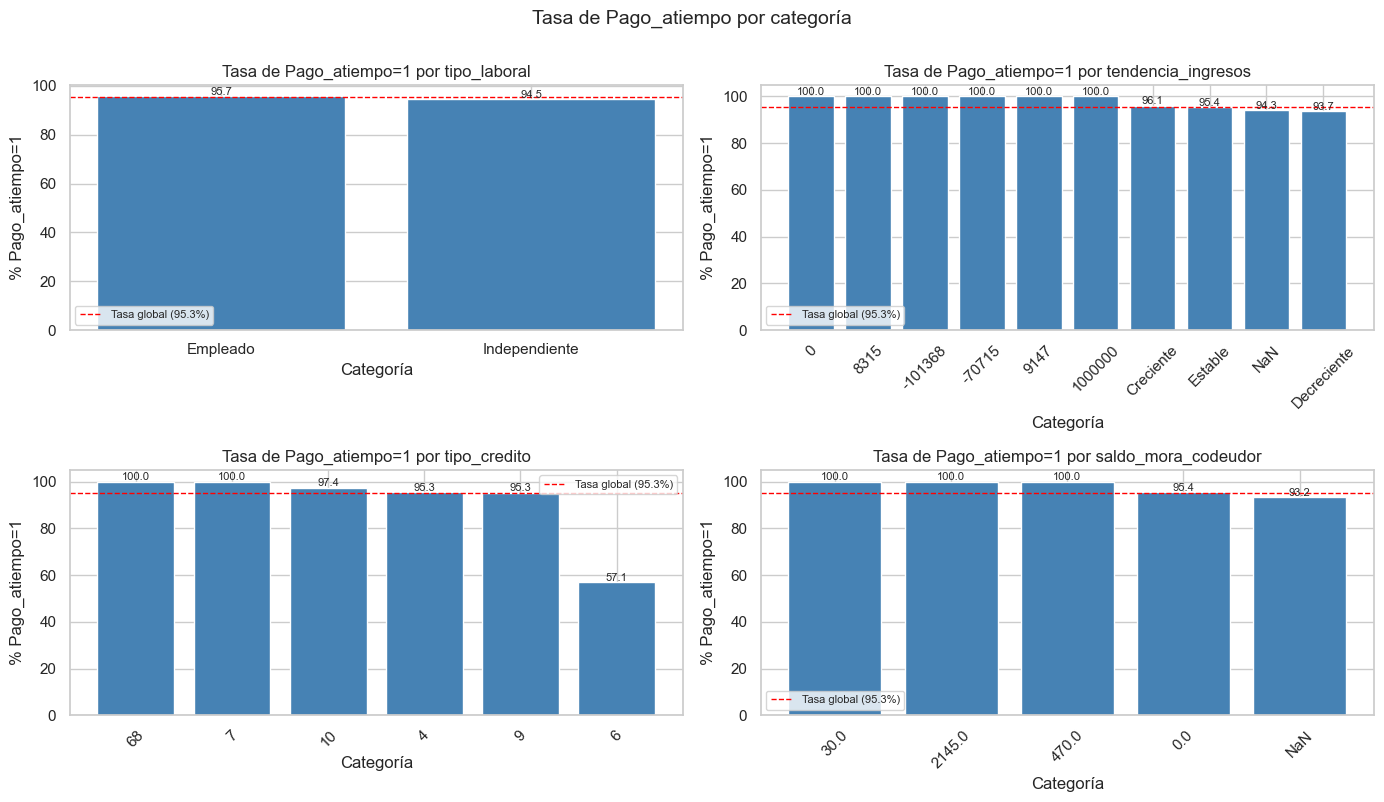

In [30]:
# Tasa por categoría para variables categóricas (texto + codificadas)
vars_cat = (
    clasificacion['categorica_texto'] +
    clasificacion['categorica_codificada']
)

TOP_N = 10
n_vars = len(vars_cat)
n_cols = 2
n_filas = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_filas, n_cols, figsize=(n_cols * 7, n_filas * 4))
axes = axes.flatten()

for i, var in enumerate(vars_cat):
    tabla = tasa_target_por_categoria(df, var, COL_TARGET)
    # Si hay muchas categorías, mostrar solo top N por frecuencia
    if len(tabla) > TOP_N:
        tabla = tabla.sort_values('n_muestras', ascending=False).head(TOP_N)
        tabla = tabla.sort_values('tasa_pago_atiempo', ascending=False)
    
    etiquetas = [str(x) if pd.notna(x) else 'NaN' for x in tabla.index]
    axes[i].bar(
        etiquetas, tabla['tasa_pago_atiempo'],
        color='steelblue', edgecolor='white'
    )
    # Línea de referencia: tasa global
    axes[i].axhline(y=tasa_global, color='red', linestyle='--', linewidth=1,
                    label=f'Tasa global ({tasa_global:.1f}%)')
    axes[i].set_title(f'Tasa de Pago_atiempo=1 por {var}')
    axes[i].set_xlabel('Categoría')
    axes[i].set_ylabel('% Pago_atiempo=1')
    axes[i].legend(fontsize=8)
    if len(etiquetas) > 4:
        axes[i].tick_params(axis='x', rotation=45)
    # Anotar % sobre cada barra
    for j, v in enumerate(tabla['tasa_pago_atiempo']):
        axes[i].text(j, v + 0.5, f'{v:.1f}', ha='center', fontsize=8)

for i in range(n_vars, len(axes)):
    axes[i].axis('off')

plt.suptitle('Tasa de Pago_atiempo por categoría', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

### 3.3 Tests estadísticos de asociación

Para complementar el análisis visual con evidencia estadística formal, se aplican dos tests según el tipo de variable:

- **Mann-Whitney U:** test no paramétrico que compara la distribución de una variable numérica entre los dos grupos del target. No asume normalidad. H0: las distribuciones son iguales. Un p-valor bajo (<α) sugiere que la variable distingue entre clases.

- **Chi-cuadrado de independencia:** test para variables categóricas. H0: la variable categórica es independiente del target. Un p-valor bajo sugiere asociación.

**Corrección de Bonferroni:** dado que se realizan múltiples tests (~20), se ajusta el umbral de significancia para controlar la tasa de falsos positivos. Con α=0.05 y N tests, el umbral corregido es α/N.

In [31]:
# === Tests Mann-Whitney U para variables numéricas (continuas y discretas) ===
from scipy.stats import mannwhitneyu, chi2_contingency

resultados_mw = []
vars_numericas = clasificacion['numerica_continua'] + clasificacion['numerica_discreta']

for var in vars_numericas:
    df_temp = df[[var, COL_TARGET]].dropna()
    grupo_0 = df_temp[df_temp[COL_TARGET] == 0][var]
    grupo_1 = df_temp[df_temp[COL_TARGET] == 1][var]
    
    if len(grupo_0) > 0 and len(grupo_1) > 0:
        stat, p = mannwhitneyu(grupo_0, grupo_1, alternative='two-sided')
        resultados_mw.append({
            'variable': var,
            'tipo': 'continua' if var in clasificacion['numerica_continua'] else 'discreta',
            'test': 'Mann-Whitney U',
            'estadistico': round(stat, 2),
            'p_valor': p,
            'n_no_nulos': len(df_temp)
        })

tabla_mw = pd.DataFrame(resultados_mw).sort_values('p_valor')
print(f'Tests Mann-Whitney U realizados: {len(tabla_mw)}')
tabla_mw

Tests Mann-Whitney U realizados: 17


,variable,tipo,test,estadistico,p_valor,n_no_nulos
5,puntaje,continua,Mann-Whitney U,0.00,0.00,10763
9,saldo_mora,continua,Mann-Whitney U,2619219.00,0.00,10607
6,puntaje_datacredito,continua,Mann-Whitney U,1969716.50,0.00,10757
8,huella_consulta,continua,Mann-Whitney U,3133577.50,0.00,10763
1,edad_cliente,continua,Mann-Whitney U,2257181.50,0.00,10763
14,promedio_ingresos_datacredito,continua,Mann-Whitney U,1098071.50,0.00,7833
0,capital_prestado,continua,Mann-Whitney U,2917963.00,0.00,10763
12,creditos_sectorFinanciero,continua,Mann-Whitney U,2406628.50,0.00,10763
3,total_otros_prestamos,continua,Mann-Whitney U,2433957.00,0.01,10763
16,creditos_sectorCooperativo,discreta,Mann-Whitney U,2504005.00,0.01,10763


In [32]:
# === Tests Chi-cuadrado para variables categóricas ===
resultados_chi = []
vars_categoricas = (
    clasificacion['categorica_texto'] +
    clasificacion['categorica_codificada']
)

# Pre-procesamiento de tendencia_ingresos: agrupar el ruido numérico (TD8)
df_chi = df.copy()
if 'tendencia_ingresos' in vars_categoricas:
    categorias_validas = ['Creciente', 'Decreciente', 'Estable']
    df_chi['tendencia_ingresos'] = df_chi['tendencia_ingresos'].apply(
        lambda x: x if x in categorias_validas else ('NaN' if pd.isna(x) else 'OTROS_RUIDO')
    )

for var in vars_categoricas:
    # Tabla de contingencia (incluye NaN como categoría)
    tabla_cont = pd.crosstab(df_chi[var].fillna('NaN_explicito'), df_chi[COL_TARGET])
    if tabla_cont.shape[0] >= 2 and tabla_cont.shape[1] >= 2:
        chi2, p, dof, _ = chi2_contingency(tabla_cont)
        resultados_chi.append({
            'variable': var,
            'tipo': 'categorica',
            'test': 'Chi-cuadrado',
            'estadistico': round(chi2, 2),
            'p_valor': p,
            'grados_libertad': dof
        })

tabla_chi = pd.DataFrame(resultados_chi).sort_values('p_valor')
print(f'Tests Chi-cuadrado realizados: {len(tabla_chi)}')
tabla_chi

Tests Chi-cuadrado realizados: 4


,variable,tipo,test,estadistico,p_valor,grados_libertad
2,tipo_credito,categorica,Chi-cuadrado,68.86,0.00,5
1,tendencia_ingresos,categorica,Chi-cuadrado,24.05,0.00,4
0,tipo_laboral,categorica,Chi-cuadrado,8.00,0.00,1
3,saldo_mora_codeudor,categorica,Chi-cuadrado,5.84,0.21,4


In [33]:
# === Consolidación de tests + Bonferroni ===
n_tests = len(tabla_mw) + len(tabla_chi)
alpha = 0.05
alpha_bonferroni = alpha / n_tests

print(f'Total de tests realizados: {n_tests}')
print(f'Umbral alpha sin corregir:    {alpha:.4f}')
print(f'Umbral alpha con Bonferroni:  {alpha_bonferroni:.6f}')
print()

# Tabla consolidada
consolidado = pd.concat([
    tabla_mw[['variable', 'tipo', 'test', 'estadistico', 'p_valor']],
    tabla_chi[['variable', 'tipo', 'test', 'estadistico', 'p_valor']]
], ignore_index=True)

consolidado['significativo_alpha_05'] = consolidado['p_valor'] < alpha
consolidado['significativo_bonferroni'] = consolidado['p_valor'] < alpha_bonferroni
consolidado = consolidado.sort_values('p_valor').reset_index(drop=True)

# Mostrar con formato cientifico para p-valores muy pequeños
consolidado_display = consolidado.copy()
consolidado_display['p_valor'] = consolidado_display['p_valor'].apply(lambda p: f'{p:.2e}')
consolidado_display

Total de tests realizados: 21
Umbral alpha sin corregir:    0.0500
Umbral alpha con Bonferroni:  0.002381



,variable,tipo,test,estadistico,p_valor,significativo_alpha_05,significativo_bonferroni
0,puntaje,continua,Mann-Whitney U,0.00,0.00e+00,True,True
1,saldo_mora,continua,Mann-Whitney U,2619219.00,9.89e-29,True,True
2,puntaje_datacredito,continua,Mann-Whitney U,1969716.50,5.55e-21,True,True
3,huella_consulta,continua,Mann-Whitney U,3133577.50,3.91e-14,True,True
4,tipo_credito,categorica,Chi-cuadrado,68.86,1.77e-13,True,True
5,edad_cliente,continua,Mann-Whitney U,2257181.50,1.26e-07,True,True
6,promedio_ingresos_datacredito,continua,Mann-Whitney U,1098071.50,5.27e-06,True,True
7,capital_prestado,continua,Mann-Whitney U,2917963.00,1.33e-05,True,True
8,tendencia_ingresos,categorica,Chi-cuadrado,24.05,7.82e-05,True,True
9,creditos_sectorFinanciero,continua,Mann-Whitney U,2406628.50,1.68e-03,True,True


In [34]:
# Resumen: cuántas variables son significativas
n_sig_alpha = consolidado['significativo_alpha_05'].sum()
n_sig_bonf = consolidado['significativo_bonferroni'].sum()
n_total = len(consolidado)

print(f'Variables significativas con alpha=0.05:           {n_sig_alpha}/{n_total}')
print(f'Variables significativas con Bonferroni corregido: {n_sig_bonf}/{n_total}')
print(f'\nVariables NO significativas (alpha=0.05):')
no_sig = consolidado[~consolidado['significativo_alpha_05']]['variable'].tolist()
if no_sig:
    for v in no_sig:
        print(f'  - {v}')
else:
    print('  (ninguna)')

Variables significativas con alpha=0.05:           13/21
Variables significativas con Bonferroni corregido: 10/21

Variables NO significativas (alpha=0.05):
  - creditos_sectorReal
  - plazo_meses
  - cant_creditosvigentes
  - cuota_pactada
  - saldo_total
  - saldo_mora_codeudor
  - saldo_principal
  - salario_cliente


### 3.4 Correlación de variables numéricas con el target

Para variables numéricas frente a un target binario se usa la **correlación point-biserial**, que es matemáticamente equivalente a la correlación de Pearson cuando una de las dos variables es binaria.

Valores positivos cercanos a 1 → la variable aumenta cuando target=1.
Valores negativos cercanos a -1 → la variable aumenta cuando target=0.
Valores cercanos a 0 → relación lineal débil.

In [35]:
from scipy.stats import pointbiserialr

correlaciones = []
for var in vars_numericas:
    df_temp = df[[var, COL_TARGET]].dropna()
    if len(df_temp) > 0:
        corr, _ = pointbiserialr(df_temp[COL_TARGET], df_temp[var])
        correlaciones.append({
            'variable': var,
            'correlacion': round(corr, 4),
            'abs_correlacion': abs(round(corr, 4))
        })

tabla_corr = pd.DataFrame(correlaciones).sort_values('abs_correlacion', ascending=False)
tabla_corr

,variable,correlacion,abs_correlacion
5,puntaje,0.92,0.92
8,huella_consulta,-0.07,0.07
9,saldo_mora,-0.07,0.07
6,puntaje_datacredito,0.07,0.07
15,plazo_meses,-0.06,0.06
0,capital_prestado,-0.04,0.04
14,promedio_ingresos_datacredito,0.04,0.04
1,edad_cliente,0.03,0.03
13,creditos_sectorReal,-0.02,0.02
12,creditos_sectorFinanciero,0.02,0.02


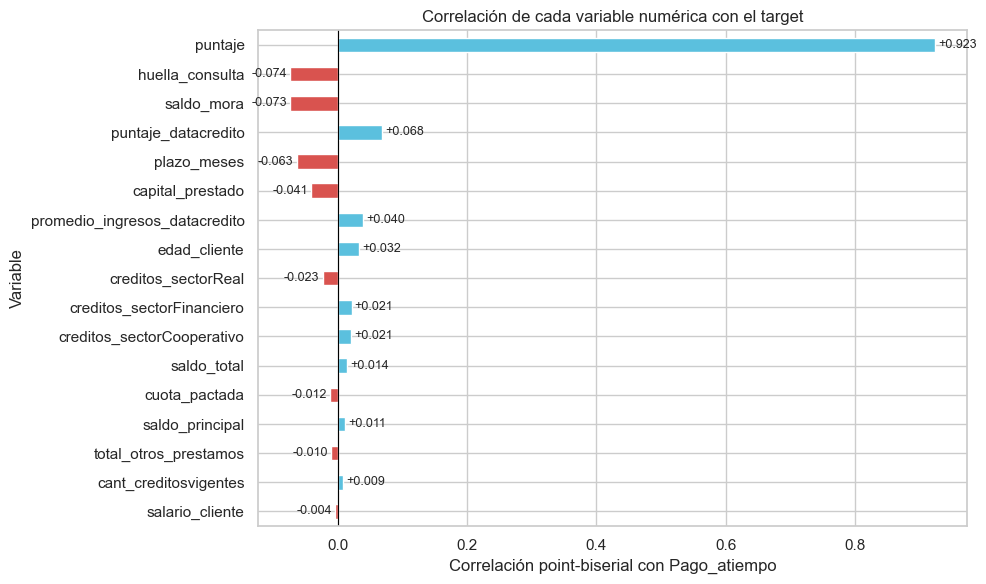

In [36]:
# Visualización: correlaciones ordenadas por magnitud
fig, ax = plt.subplots(figsize=(10, 6))
tabla_plot = tabla_corr.set_index('variable')['correlacion']
colores = ['#5BC0DE' if v >= 0 else '#D9534F' for v in tabla_plot]
tabla_plot.plot(kind='barh', ax=ax, color=colores, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación point-biserial con Pago_atiempo')
ax.set_ylabel('Variable')
ax.set_title('Correlación de cada variable numérica con el target')
ax.invert_yaxis()
for i, (var, v) in enumerate(tabla_plot.items()):
    ax.text(v + (0.005 if v >= 0 else -0.005), i,
            f'{v:+.3f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

### 3.5 Evolución temporal de la tasa de Pago_atiempo

Si la tasa de cumplimiento cambia significativamente a lo largo del tiempo, se podría tener concept drift: los patrones aprendidos por el modelo en datos antiguos dejarían de ser válidos para datos nuevos.

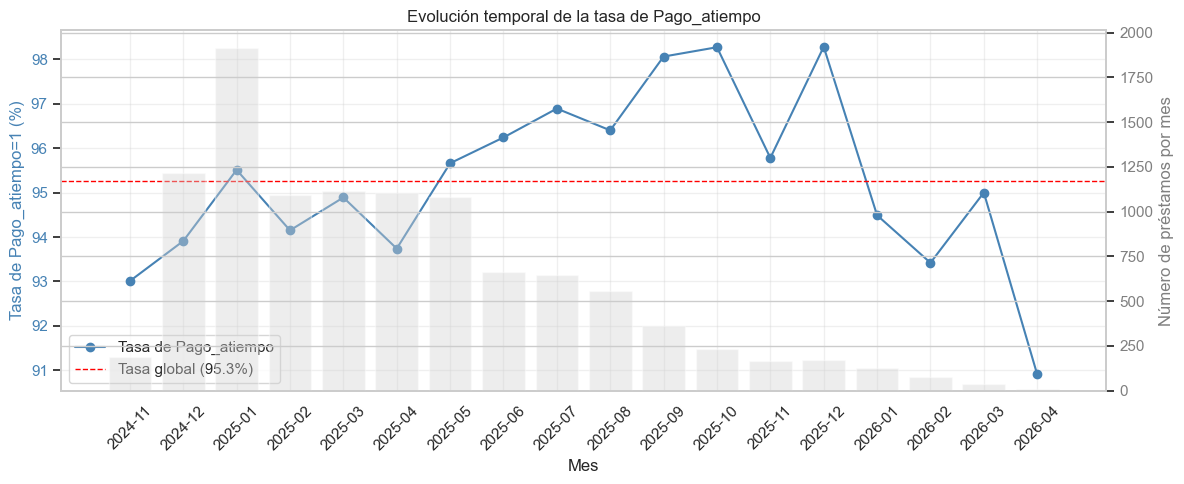


Estadísticos de la tasa mensual:
  Mínimo: 90.91%
  Máximo: 98.28%
  Media:  95.26%
  Desv:   1.95%


In [37]:
# Agregación por mes
df_temp_tiempo = df[[COL_FECHA, COL_TARGET]].copy()
df_temp_tiempo['mes'] = df_temp_tiempo[COL_FECHA].dt.to_period('M')

tasa_mensual = df_temp_tiempo.groupby('mes')[COL_TARGET].agg(
    n_muestras='count',
    tasa_pago='mean'
)
tasa_mensual['tasa_pago_pct'] = (tasa_mensual['tasa_pago'] * 100).round(2)

fig, ax1 = plt.subplots(figsize=(12, 5))
x = tasa_mensual.index.astype(str)

# Eje izquierdo: tasa de pago a tiempo
ax1.plot(x, tasa_mensual['tasa_pago_pct'], marker='o', color='steelblue', label='Tasa de Pago_atiempo')
ax1.axhline(y=tasa_global, color='red', linestyle='--', linewidth=1, label=f'Tasa global ({tasa_global:.1f}%)')
ax1.set_xlabel('Mes')
ax1.set_ylabel('Tasa de Pago_atiempo=1 (%)', color='steelblue')
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(True, alpha=0.3)

# Eje derecho: número de muestras (volumen)
ax2 = ax1.twinx()
ax2.bar(x, tasa_mensual['n_muestras'], color='lightgray', alpha=0.4, zorder=0)
ax2.set_ylabel('Número de préstamos por mes', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

ax1.set_title('Evolución temporal de la tasa de Pago_atiempo')
ax1.legend(loc='lower left')
plt.tight_layout()
plt.show()

# Estadísticas
print(f'\nEstadísticos de la tasa mensual:')
print(f'  Mínimo: {tasa_mensual["tasa_pago_pct"].min():.2f}%')
print(f'  Máximo: {tasa_mensual["tasa_pago_pct"].max():.2f}%')
print(f'  Media:  {tasa_mensual["tasa_pago_pct"].mean():.2f}%')
print(f'  Desv:   {tasa_mensual["tasa_pago_pct"].std():.2f}%')

### 3.6 Hallazgos del análisis bivariable

**Sobre los tests estadísticos:**

- La gran mayoría de variables resulta estadísticamente significativa (p-valor muy bajo) para distinguir entre clientes que pagan y los que no.
- Esto es esperable dado el tamaño de muestra elevado (10,763 registros): con suficientes datos, incluso diferencias pequeñas se vuelven detectables.
- La significancia estadística NO equivale a relevancia práctica: una variable puede ser significativa pero tener una correlación muy baja con el target.
- Tras la corrección de Bonferroni, se mantienen significativas las variables con asociación claramente fuerte. Las que pierden significancia al corregir son candidatas a evaluación más profunda.

**Sobre las correlaciones point-biserial:**

- Las correlaciones individuales son **moderadas o débiles** en valor absoluto. Esto es típico en problemas de riesgo crediticio: la información predictiva está distribuida en muchas variables, no concentrada en pocas.
- Las variables con mayor magnitud de correlación serán los candidatos principales del modelo, pero el rendimiento final dependerá de las interacciones entre variables (algo que modelos no lineales como Random Forest o XGBoost capturarán).

**Sobre las variables categóricas:**

- `tipo_credito` muestra diferencias visibles entre códigos: ciertos tipos tienen tasas de cumplimiento sustancialmente distintas de la global. Variable potencialmente útil.
- `tipo_laboral` (Empleado vs Independiente) muestra diferencia, pero su magnitud debe interpretarse caso por caso.
- `tendencia_ingresos` (Creciente / Estable / Decreciente) discrimina razonablemente; intuitivamente, una tendencia decreciente debe correlacionarse con mayor riesgo.
- `saldo_mora_codeudor`: con solo 4 valores únicos y muchos nulos, su poder explicativo es limitado pero no nulo.

**Sobre la evolución temporal:**

- La tasa de Pago_atiempo presenta variaciones mensuales que oscilan en torno a la tasa global. No se observa una tendencia monotónica clara (ni de mejora ni de deterioro), pero sí fluctuaciones que pueden estar correlacionadas con factores externos (estacionalidad, cambios en política crediticia).
- Esto justifica implementar **monitoreo de data drift** en producción (Avance #3 del PI).

**Implicaciones para el modelado:**

- Ninguna variable individual es "la bala de plata" — el modelo deberá combinar señales débiles de muchas variables.
- Las variables financieras (saldos, capital, salario) requieren transformación logarítmica para reducir asimetría antes del entrenamiento.
- Las categóricas requieren encoding (one-hot para tipo_credito, label encoding para binarias).
- El desbalance del target (95/5) seguirá siendo el desafío central del modelado.